In [16]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [17]:
# ==========================================
# Load Cleaned Dataset
# ==========================================
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay)



In [18]:
df = pd.read_csv(r"D:\AI course\ML_DS_CapstoneProject\Dataset\Placement_Data_Cleaned.csv")
X = df.drop("status", axis=1)
y = df["status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# ==========================================
# Train Final Model
# (Logistic Regression — chosen from Folder 4 , best Macro F1 = 0.846)
# ==========================================

final_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Final model trained: Logistic Regression")

Final model trained: Logistic Regression


In [20]:
# ==========================================
# Final Model Evaluation
# ==========================================

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 (Class 1):", f1_score(y_test, y_pred))
print("F1 (Macro)  :", f1_score(y_test, y_pred, average="macro"))

print("\n================ CLASSIFICATION REPORT ================\n")
print(classification_report(y_test, y_pred, target_names=["Not Placed", "Placed"]))

Accuracy : 0.8604651162790697
Precision: 0.9615384615384616
Recall   : 0.8333333333333334
F1 (Class 1): 0.8928571428571429
F1 (Macro)  : 0.8464285714285715

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

  Not Placed       0.71      0.92      0.80        13
      Placed       0.96      0.83      0.89        30

    accuracy                           0.86        43
   macro avg       0.83      0.88      0.85        43
weighted avg       0.88      0.86      0.86        43



Confusion Matrix:
 [[12  1]
 [ 5 25]]


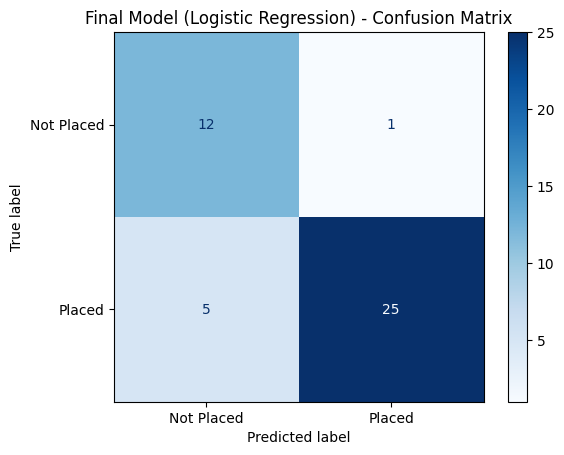

In [21]:
# ==========================================
# Confusion Matrix (Final)
# ==========================================

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Placed", "Placed"])
disp.plot(cmap="Blues")
plt.title("Final Model (Logistic Regression) - Confusion Matrix")
plt.show()


================ FEATURE COEFFICIENTS ================

                  Feature  Coefficient
12             workex_Yes     1.555025
11      degree_t_Sci&Tech    -1.079313
5                gender_M     0.966147
6            ssc_b_Others     0.507806
9           hsc_s_Science    -0.473704
8          hsc_s_Commerce    -0.355085
0                   ssc_p     0.212245
4                   mba_p    -0.202016
2                degree_p     0.163618
10        degree_t_Others    -0.130726
1                   hsc_p     0.096608
13  specialisation_Mkt&HR    -0.095972
7            hsc_b_Others     0.064227
3                 etest_p    -0.005337


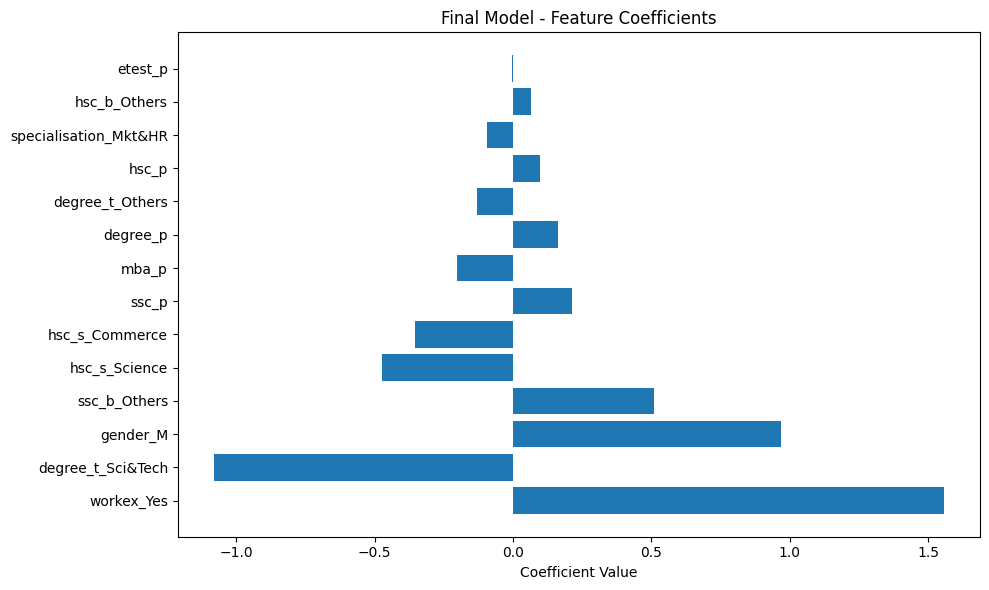

In [22]:
# ==========================================
# Feature Coefficients (Final Model Interpretation)
# ==========================================

coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": final_model.coef_[0]}).sort_values(by="Coefficient", key=abs, ascending=False)


print("\n================ FEATURE COEFFICIENTS ================\n")
print(coef_df)

plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Final Model - Feature Coefficients")
plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# Save Final Model
# ==========================================
joblib.dump(final_model, "final_placement_model.pkl")
print("Final model saved as 'final_placement_model.pkl'")

Final model saved as 'final_placement_model.pkl'


In [24]:
# ==========================================
# Reusable Prediction Function
# ( predict placement status for a NEW student)
# ==========================================
def predict_placement(student_dict):
    """
    student_dict must contain all feature columns used in training.
    Example:
    {
        "ssc_p": 75.0, "hsc_p": 70.0, "degree_p": 68.0,
        "etest_p": 80.0, "mba_p": 60.0,
        "gender_M": True, "ssc_b_Others": True, "hsc_b_Others": True,
        "hsc_s_Commerce": True, "hsc_s_Science": False,
        "degree_t_Others": False, "degree_t_Sci&Tech": True,
        "workex_Yes": False, "specialisation_Mkt&HR": True
    }
    """
    input_df = pd.DataFrame([student_dict])
    input_df = input_df[X.columns]  # ensure correct column order
    prediction = final_model.predict(input_df)[0]
    probability = final_model.predict_proba(input_df)[0][1]

    result = "Placed" if prediction == 1 else "Not Placed"
    print(f"Prediction: {result}")
    print(f"Probability of Placement: {probability:.2%}")
    return result

In [25]:
# ==========================================
# Example Usage
# ==========================================
sample_student = {
    "ssc_p": 78.5, "hsc_p": 72.0, "degree_p": 70.0,
    "etest_p": 65.0, "mba_p": 60.0,
    "gender_M": True, "ssc_b_Others": True, "hsc_b_Others": False,
    "hsc_s_Commerce": True, "hsc_s_Science": False,
    "degree_t_Others": False, "degree_t_Sci&Tech": True,
    "workex_Yes": True, "specialisation_Mkt&HR": False
}

predict_placement(sample_student)

Prediction: Placed
Probability of Placement: 99.76%


'Placed'